# Query Notebook

This notebook contains the 7 queries used to perform complex analysis on the football database. 

### AI USE

**Please note that AI has been used for the following, and ChatGbT chat logs have been uploaded to the repository. AI was used to help us understand how to effectively use cypher functions, visualise results and create interactive functions. It was not used to write our entire queries, but rather as an aid to write effective queries and to understand our errors.**

- How to do either/or when filtering on the [:HOME_TEAM|AWAY_TEAM] relationship between MATCH and SQUAD
- How to turn data to a float within a cypher query to perform proportion calculations
- Understand how to correctly use CASE and UNION ALL statements
- How to colour code bar chart in vega altair
- How to calculate frequency of matches using COUNT(*)
- How to display two bar charts next to each other in vega altair
- How to use multiple case and with statements combined in the 'Which Teams Have the Greatest Home Advantage' query
- In highest defender growth query, chatgpt was used to help design cypher query specifically with using unwind in order to loop through seasons

In [111]:
import os
import requests
import pickle
import pandas as pd
import altair as alt
import matplotlib.pyplot as plt
import ipywidgets as widgets
from io import BytesIO
from PIL import Image as PILImage
from dotenv import load_dotenv
from bs4 import BeautifulSoup
from neo4j import GraphDatabase
from neo4j.exceptions import ServiceUnavailable

from IPython.display import display, clear_output, Image
from ipywidgets import VBox, Button, Dropdown, Output
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.image import imread
from mplsoccer import VerticalPitch
from utilities.cypher_query_loader import CypherQueryLoader
from dotenv import load_dotenv 
load_dotenv(dotenv_path = os.path.join(os.getcwd(),'config/.env'))

True

In [112]:
USER=os.getenv("NEO4J_USERNAME")
URI=os.getenv("NEO4J_URI")
PASSWORD = os.getenv("NEO4J_PASSWORD")
driver = GraphDatabase.driver(URI, auth=(USER, PASSWORD))

# Query 1: Impact of Player Injury 

The following query analyses the impact of an individual players injury on the teams success. It does this by comparing the win ratio of the players teams matches when the player is and is not playing. This gives us insight into how impactful a player is on the teams success. It should be noted that there may be other factors that effect the win rates, such as weather and opposition team. This query focuses on the season 2022-2023 and only analyses players who played over 3 matches as some players may just be very short term loans.

### STEP 1: Creating a list of names of players who played over 3 matches in the 2022-2023 season 

1. The first step to this query MATCHES players to their squad and the matches they have played it.
2. Next, it usees WHERE to filter for the season of interest, 2022-2023, using the season property stored in squad.
3. Then it counts the DISTINCT matches the player has played and uses WHERE to filter these to players that have only played more than 3 matches.

### STEP 2: Calculating the win ratio for the games the player DID play
1. This query loops through the names stored in player_names_min_games to extract the win ratio for each of these players.
2. First, it uses MATCH to find the players squad, and the matches the squad has played (both home and away), and then matches this to the matches that the player played in. It also matches match to the season that it is played in.
3. Next, it uses WHERE to filter for the season of interest, 2022-2023, using the season property stored in squad and the season node.
4. The WITH is used to aggregate the number of matches played by the player. The SUM then counts how many of these matches played are wins (draw is counted as a loss). If the player’s squad is the home team and the home score is greater than the away score, or if the player’s squad is the away team and the away score is greater than the home score, it's considered a win.
5. It then RETURNS the name of the player, the total games they played their win ratio and if no games were played (total_games = 0), the win ratio is set to 0%.


### STEP 3: Calculating the win ratio for the games the player DID NOT play

*This does the exact same steps as STEP 2, however it filters for the matches that the player did not play and their squad still did, using 'AND NOT (player)-[:PLAYS_IN]->(match)'.*


### STEP 4: Creating Win Ratio Dataframe 

1. This uses the player_stats list of dictionaries to create a dataframe needed for visualisations.
2. **NOTE** that the in order to calculate the impact of their absense a WEIGHTED difference was performed. The ratios are weighted by the number of games they did/did not play. This is because if a player only missed one match, but the team won, the not playing win ratio would be 100%.

In [113]:
# Stores relevent information for each player extracted in the query, used to make dataframe 

player_stats = []

# STEP 1: Creating a list of names of players who played over 3 matches in the 2022-2023 season 
with driver.session(database="neo4j") as session:
    query = """
    MATCH (player:Player)-[:IS_IN_SQUAD]->(squad:Squad)
    MATCH (player)-[plays:PLAYS_IN]->(match:Match)
    WHERE squad.season = "2022-2023"
    WITH player.name AS player_name, COUNT(DISTINCT match) AS match_count
    WHERE match_count > 3
    RETURN player_name, match_count
    ORDER BY match_count DESC
    """
    result = session.run(query)
    player_names_min_games = [record["player_name"] for record in result]

# STEP 2: Calculating the win ratio for the games the player DID play
# for loop to loop through the list of player names created in the previous query.
for player in player_names_min_games:
    with driver.session(database="neo4j") as session:
        query = """
        MATCH (player:Player {name:$player_name})
        MATCH (player)-[:IS_IN_SQUAD]->(squad:Squad)
        MATCH (squad)-[:HOME_TEAM|AWAY_TEAM]-(match:Match)
        MATCH (player)-[:PLAYS_IN]->(match)
        MATCH (match)-[:IS_PART_OF]->(season:Season)
        WHERE season.season = "2022-2023" AND squad.season = "2022-2023"
        WITH 
            player.name AS player_name,
            COUNT(match) AS total_games,
            SUM(CASE 
                WHEN ((match)-[:HOME_TEAM]->(squad)  AND match.home_score > match.away_score) 
                  OR ((match)-[:AWAY_TEAM]->(squad) AND match.away_score > match.home_score) 
                THEN 1 ELSE 0 END) AS wins
        RETURN 
            player_name,
            total_games,
            CASE 
                WHEN total_games > 0 
                THEN (toFloat(wins) / total_games) * 100 
                ELSE 0 
            END AS playing_win_ratio
        """
        result = session.run(query, {"player_name": player})
        record = result.single()  # Extract single record
        if record:  # Ensure there is a result
            player_name = record["player_name"]
            matches_played = record["total_games"]
            playing_win_ratio = record["playing_win_ratio"]
        else:
            player_name = player
            matches_played = 0
            playing_win_ratio = 0

    # STEP 3: Calculating the win ratio for the games the player DID NOT play
    with driver.session(database="neo4j") as session:
        query = """
        MATCH (player:Player {name:$player_name})
        MATCH (player)-[:IS_IN_SQUAD]->(squad:Squad)
        MATCH (squad)-[:HOME_TEAM|AWAY_TEAM]-(match:Match)
        MATCH (match)-[:IS_PART_OF]->(season:Season)
        WHERE season.season = "2022-2023" AND squad.season = "2022-2023"
        AND NOT (player)-[:PLAYS_IN]->(match)
        WITH 
            player.name AS player_name,
            COUNT(match) AS total_games,
            SUM(CASE 
                WHEN (match)-[:HOME_TEAM]->(squad) AND match.home_score > match.away_score THEN 1 
                WHEN (match)-[:AWAY_TEAM]->(squad) AND match.away_score > match.home_score THEN 1
                ELSE 0 END) AS wins
        RETURN 
            player_name,
            total_games,
            CASE 
                WHEN total_games > 0 THEN (toFloat(wins) / total_games) * 100 
                ELSE 0 
            END AS not_playing_win_ratio
        """ 
        result = session.run(query, {"player_name": player})
        record = result.single()  # extracts single record from the results 
        
        # stores the relevent information to be appended to player stats
        if record: 
            not_playing_win_ratio = record["not_playing_win_ratio"]
            games_missed = record["total_games"]
        else:
            not_playing_win_ratio = 0
            games_missed = 0

    # STEP 4: Create dataframe of the relevent information on player and win ratio
    player_stats.append({
        "Player": player_name,
        "Playing Win Ratio (%)": playing_win_ratio,
        "Not Playing Win Ratio (%)": not_playing_win_ratio,
        "Matches Played": matches_played,
        "Games Missed": games_missed
    })


winratio_df = pd.DataFrame(player_stats)


# This weights the win ratios by the number of matches the player did and did not play
winratio_df['Weighted Difference'] = (
    (winratio_df['Matches Played'] * winratio_df['Playing Win Ratio (%)']) - 
    (winratio_df['Games Missed'] * winratio_df['Not Playing Win Ratio (%)'])
) / (winratio_df['Matches Played'] + winratio_df['Games Missed'])


winratio_df


KeyboardInterrupt: 

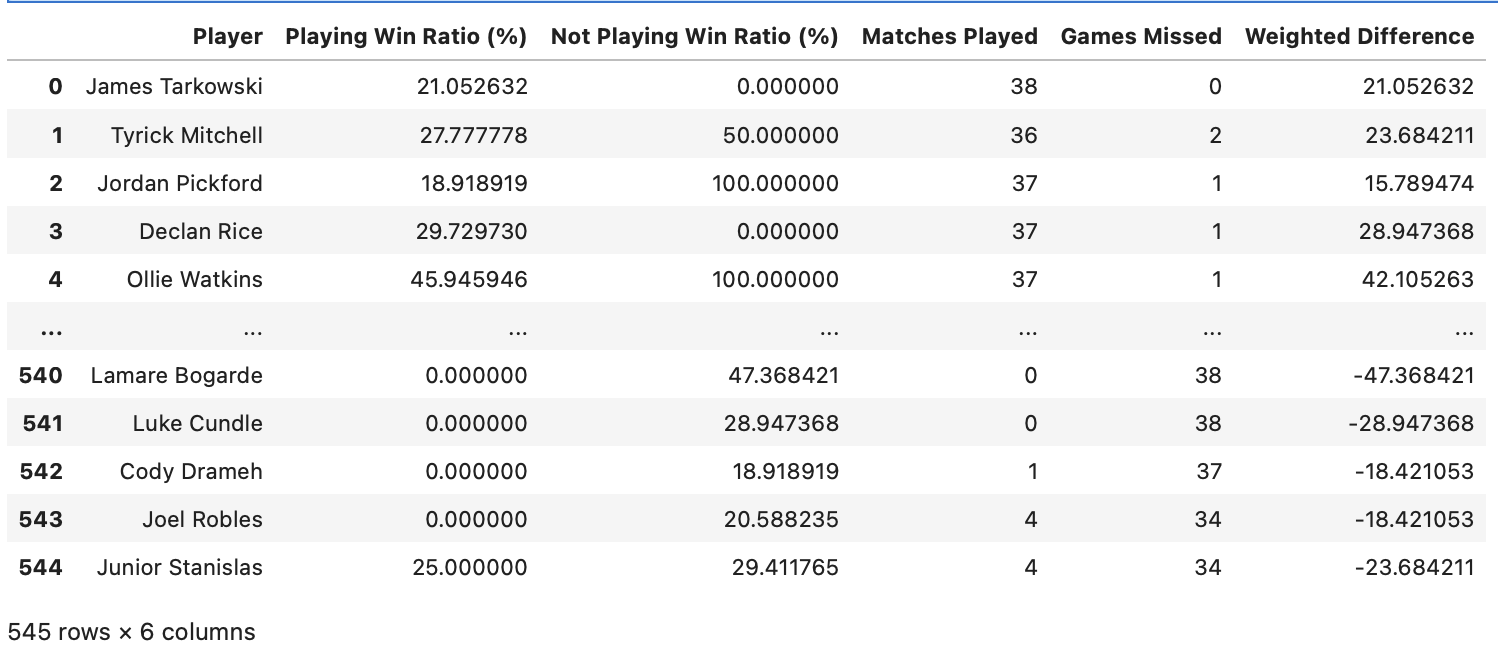

In [8]:

Image("images/winratio_df.png")

## Query 4 Visualisation: Impact of Injury on Win Rates

**BAR CHART:** Visualisation of the top and bottom 20 players based on win ratios. This shows the players whose absense had the biggest and least impact on their teams team win rate.

In [ ]:
# There are 545 players and graphing all of these would not be logical 
# This sort the dataframe based on the weighted difference and then finds the top and bottom players 
df_sorted = winratio_df.sort_values(by='Weighted Difference', ascending=False)
top_20 = df_sorted.head(20)
bottom_20 = df_sorted.tail(20)

# stores the top and bttom 20 players to a new df
sorted_winratio_df = pd.concat([top_20, bottom_20])
winratio_df.reset_index(drop=True, inplace=True)


# Creates a bar chart using this sorted winratio_df
sorted_winratio_chart = alt.Chart(sorted_winratio_df).mark_bar(
    opacity=0.8  # Bar opacity
).encode(
    x=alt.X('Player:N', sort='-y', title='Player', axis=alt.Axis(labelAngle=-45)),
    y=alt.Y('Weighted Difference:Q', title='Change in Win Rates'),
    color=alt.Color('Weighted Difference:Q', 
                      scale=alt.Scale(domain=[-50, 0, 50], 
                                        range=['red', 'lightgray', 'green'])),
    tooltip=['Player:N', 'Weighted Difference:Q']
).configure_axis(
    labelColor='black',  # Axis label color
    titleColor='blue'  # Axis title color
).properties(
    title='The Impact of Player Absence on Win Rates'
)


sorted_winratio_chart

/Users/maddonk/anaconda3/lib/python3.11/site-packages/altair/utils/core.py:410: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


alt.Chart(...)

**SCATTER PLOT OF MATCHES VS WIN RATES:** This plots the relationship between matches played by a player (X) and their change in win rates when not playing for the team (Y). It shows a strong positive correlation between matches played and win rates. This suggets that better players (that have high change in win rates) play more matches.

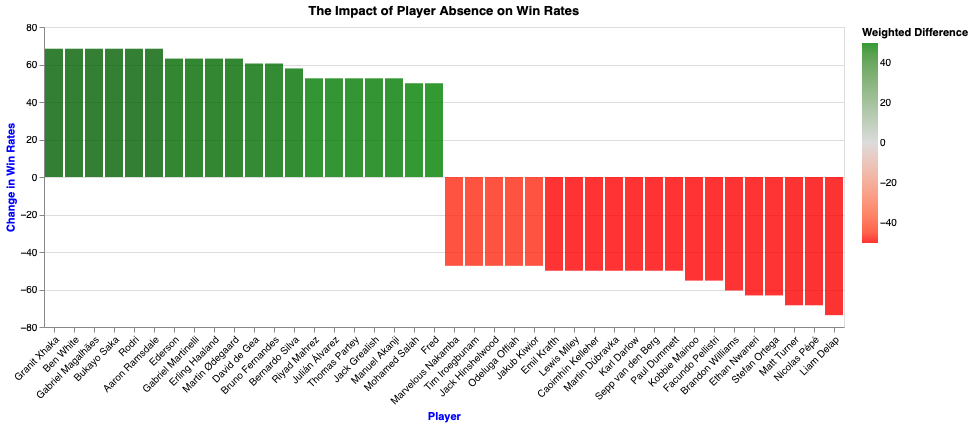

In [10]:
Image("images/sorted_winratio_chart.png")

In [ ]:
matches_winratio_chart = alt.Chart(winratio_df).mark_point(
    color='blue',
    filled=True,
    opacity=0.8,
    size=15
).encode(
    x=alt.X('Matches Played:Q', title='Matches Played'),
    y=alt.Y('Weighted Difference:Q', title='Change in Win Rates'),
    tooltip=['Player:N', 'Matches Played:Q', 'Weighted Difference:Q']
).configure_axis(
    labelColor='black',  
    titleColor='black'  
).properties(
    title='Weighted Difference by Matches Played',
    background='white'
)

matches_winratio_chart

/Users/maddonk/anaconda3/lib/python3.11/site-packages/altair/utils/core.py:410: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


alt.Chart(...)

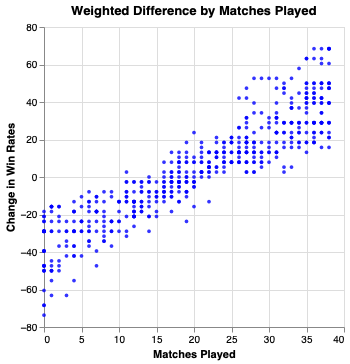

In [12]:
Image("images/matches_winratio_chart.png")

# Home Advantage Analysis

This section performs 3 seperate analysis (queries) to investigate how teams playing at their home grounds improves their win rates.

### Query 2: Distribution of Frequency of Goals in Home vs Away

1. Matches on match, and aliases it to m, then filters it for cases where home score is not NULL, meaning that match has been played.
2. WITH passes the needed data to the next part of the query, aliasing both team type and score.
3. It then RETURNS the frequecy each time home score, this is how many times a specific number of goals was scored by home teams across all the matches.
4. The data returned is then stored into a data frame (goal_distribution_df) which is used for visualisations

In [ ]:
with driver.session(database="neo4j") as session:
    query = """
    MATCH (m:Match)
    WHERE m.home_score IS NOT NULL
    WITH m.home_score AS score, 'home' AS team_type
    RETURN team_type, score AS goals_scored,
      COUNT(*) AS frequency
    ORDER BY goals_scored
    UNION ALL
    MATCH (m:Match)
    WHERE m.away_score IS NOT NULL
    WITH m.away_score AS score, 'away' AS team_type
    RETURN 
      team_type, score AS goals_scored, COUNT(*) AS frequency
    ORDER BY goals_scored
    """
    result = session.run(query)
    data = [{"team_type": record["team_type"], 
             "goals_scored": record["goals_scored"], 
             "frequency": record["frequency"]} for record in result]

# stores data in a df for later
goal_distribution_df= pd.DataFrame(data)


# plots a bar chart for the frequency of each specific number of goals for home/away
goal_distribution_chart = alt.Chart(goal_distribution_df).mark_bar().encode(
    x=alt.X('goals_scored:O', title='Goals Scored', axis=alt.Axis(labelAngle=0)),  # bars are grouped on goals scored
    y=alt.Y('frequency:Q', title='Frequency'),       
    color=alt.Color('team_type:N',                   
                    scale=alt.Scale(domain=['home', 'away'], range=['blue', 'red']),
                    legend=alt.Legend(title="Team Type")),
    column=alt.Column('team_type:N', title=None)     # separate bars for home and away
).properties(
    title='Frequency of Goals Scored: Home vs. Away',
    width=300,
    height=400
)


print(goal_distribution_df)


display(goal_distribution_chart)

   team_type  goals_scored  frequency
0       home             0        297
1       home             1        425
2       home             2        332
3       home             3        187
4       home             4         84
5       home             5         30
6       home             6         10
7       home             7          3
8       home             9          1
9       away             0        380
10      away             1        463
11      away             2        301
12      away             3        138
13      away             4         58
14      away             5         21
15      away             6          7
16      away             8          1


/Users/maddonk/anaconda3/lib/python3.11/site-packages/altair/utils/core.py:410: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


alt.Chart(...)

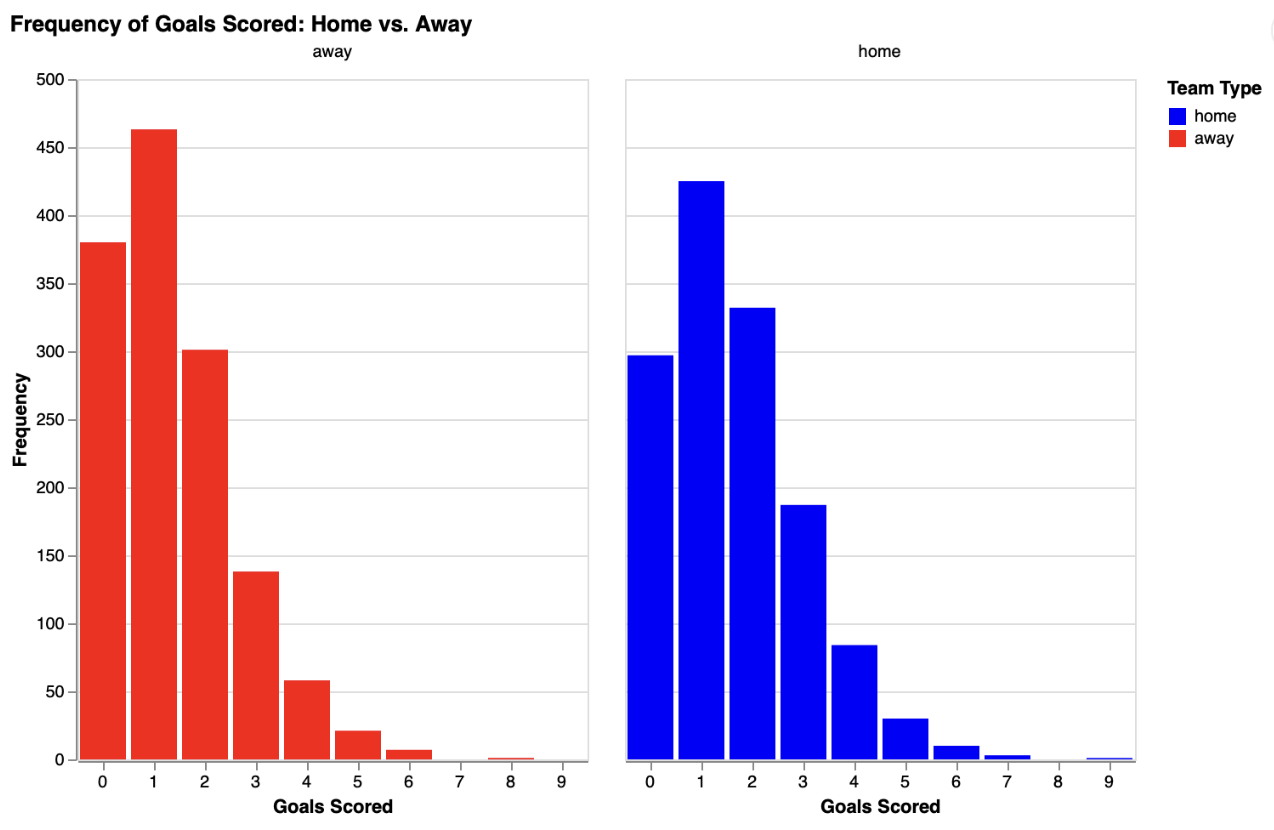

In [14]:
Image("images/goal_distribution_chart.png",width=700, height=350)

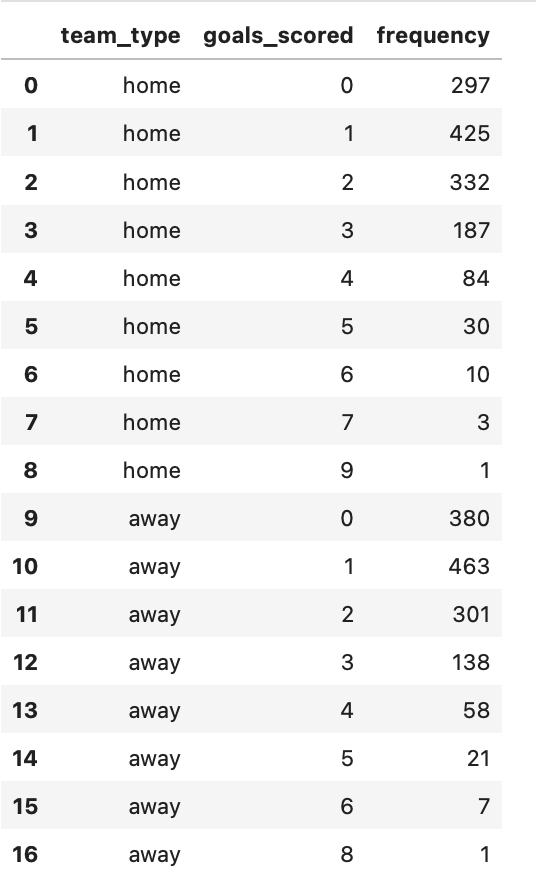

In [15]:

Image("images/goal_distribution_df.png", width=400, height=200)


### Query 3: Average Number of Goal for Home and Away 

From this distributions plotted above it is not clear the extent to which playing at home has an advantage, as the distribution of goal frequencies appear very similar. Thus, the next query quantifie the advantage. 

This returns the average goal difference for matches, categorized by match result (home win, away win, or draw). The output indicates that home teams, on average, **win by a margin of 1.974 goals**, whereas away teams **lose by 1.922 goals**. This then suggests there is a significant home advantage. 

**STEPS:**
1.  Matches on match, and aliases it to m, then filters it for cases where home/away score is not NULL, meaning that match has been played.
2.  The WITH then passes the home and away score forward and aliases them.
3.  The CASE is used to calculate the match result: if the home team's score is greater then the away team's score then result is 'home', if the away team's score is greater then the result is 'away' else the result is 'draw'.
4.  The RETURN then uses AVG to calculate the average goal difference across all the matches.

In [ ]:
with driver.session(database="neo4j") as session:
    query = """
    MATCH (m:Match)
    WHERE m.home_score IS NOT NULL AND m.away_score IS NOT NULL
    WITH 
      m.home_score AS home_score, 
      m.away_score AS away_score,
      CASE 
        WHEN m.home_score > m.away_score THEN 'home'
        WHEN m.away_score > m.home_score THEN 'away'
        ELSE 'draw'
      END AS result
    RETURN 
      result,
      AVG(home_score - away_score) AS avg_goal_difference
    """
    result = session.run(query)
    for r in result:
        if r["result"] == 'draw':
            continue
        print(f'Average goal difference for {r["result"]} team is {r["avg_goal_difference"]}')

Average goal difference for home team is 1.9738134206219307
Average goal difference for away team is -1.9227272727272728


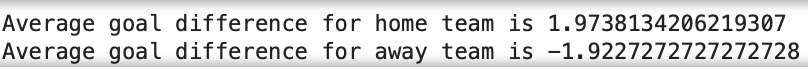

In [17]:
Image("images/average_difference.png")

### Query 3: Which Teams Have the Greatest Home Advantage 

This query matches teams that have played each other twice during the 2022-2023 season: once at team 1's home stadium and once at team 2's home stadium. By matching on the same teams under different conditions (one as the home team and the other as the away team), it allows for a more accurate comparison of performance in both teams' home stadiums. 

**STEPS:**
1. Firstly, it MATCHES all the match nodes that are the season 2022-2023 and then matches all squads to matches they played in this season using the home/away team relationships. 
2. The CASE clause the determines if the team is playing at home or away based on the relationship HOME_TEAM. It then stores this as match type.
3. The second CASE then stores 'score for', which either the home or away score depending on if they are playing at home or away.
4. The THIRD CASE assigns the opposing team's score based on whether the team is playing at home or away.
5. Next, the WITH aggregates the score_for and score_against values across all matches for each team, and groups these by team_name and match_type This calculates the total goals scored by the team when playing a type of match (home or away).
6. Next, the WITH calculates the home advantage using the total_score_for and total_score_with that were calculated in the previous WITH: For matches where the team played at home, it calculates the total score difference goals scored minus goals conceded). It then does the same for matches where the team played away.
7. It then returns the relevent data and orders it by net home advantage, which is the difference between a teams home advantage and away disadvantage.
8. This data is then stored in a dataframe.

In [ ]:
with driver.session(database="neo4j") as session:
    query = """
    MATCH (match:Match)-[:IS_PART_OF]->(season: Season {season: "2022-2023"})
    MATCH (squad:Squad {season: "2022-2023"})-[:HOME_TEAM|AWAY_TEAM]-(match)
    WITH 
      squad.team AS team_name,
      CASE 
        WHEN (squad)-[:HOME_TEAM]-(match) THEN 'home'
        ELSE 'away'
      END AS match_type,
      CASE 
        WHEN (squad)-[:HOME_TEAM]-(match) THEN match.home_score
        ELSE match.away_score
      END AS score_for,
      CASE 
        WHEN (squad)-[:HOME_TEAM]-(match) THEN match.away_score
        ELSE match.home_score
      END AS score_against
    WITH 
      team_name, match_type,
      SUM(score_for) AS total_score_for,
      SUM(score_against) AS total_score_against
    WITH 
      team_name,
      SUM(CASE WHEN match_type = 'home' THEN total_score_for - total_score_against ELSE 0 END) AS home_advantage,
      SUM(CASE WHEN match_type = 'away' THEN total_score_for - total_score_against ELSE 0 END) AS away_disadvantage
    RETURN 
      team_name, home_advantage, away_disadvantage,
      home_advantage - away_disadvantage AS net_home_advantage
    ORDER BY net_home_advantage DESC;
    """
    # extracting relevent information
    result = session.run(query)
    data = [{"team": record["team_name"], 
             "home_advantage": record["net_home_advantage"]} for record in result]


home_advantage_df= pd.DataFrame(data)
home_advantage_df


,team,home_advantage
0,Manchester Utd,37
1,Nott'ham Forest,36
2,Liverpool,30
3,Wolves,25
4,Manchester City,25
5,Brentford,22
6,Aston Villa,19
7,Bournemouth,18
8,Tottenham,17
9,West Ham,17


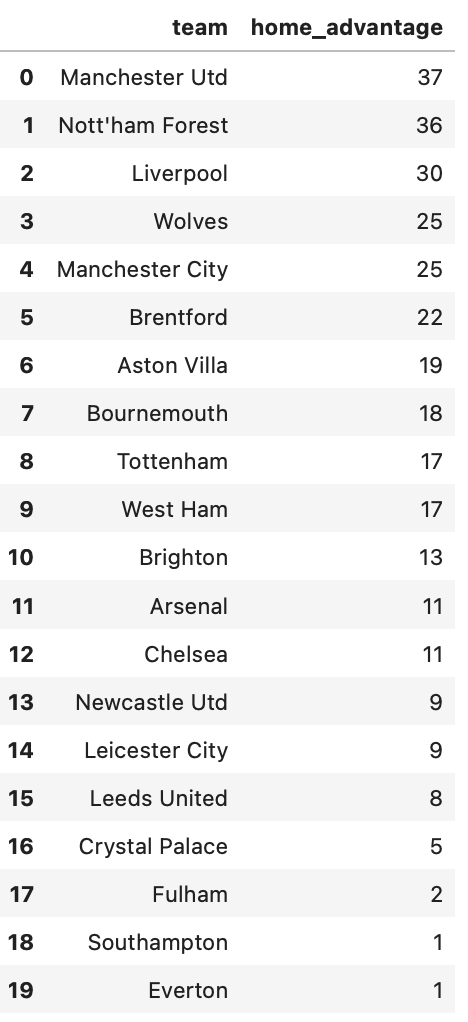

In [19]:
Image("images/home_advantage_df.png",width=400, height=200)

### Query 4 cont: Correlating home team advantage with stadium capacity

At face value, it appears as though larger teams have a greater home advantage. Therefore, the final part of the home advantage analysis, explores the relationship between capacity (stored in venue node) of home venue and home advantage 

**STEPS:**
1. First, it finds all Match nodes that are connected to a Venue node via the PLAYED_AT relationship. Then it finds the home teams for each match.
2. It then RETURNS a distinct list of teams and their stadium capacities (stadium_capacity). Logically, the venue the match is played at is the home teams stadium. DISTINCT ensures that each team appears only once, preventing duplicate entries.

In [ ]:
with driver.session(database="neo4j") as session:
    query = """
    MATCH (match:Match)-[:PLAYED_AT]->(venue:Venue)
    MATCH (match)-[:HOME_TEAM]->(squad:Squad)
    RETURN 
      DISTINCT squad.team AS team_name,  
      venue.capacity AS stadium_capacity;
    """
    result = session.run(query)
    stadium_capacities = {record["team_name"]: record["stadium_capacity"] for record in result}
    home_advantage_df["stadium_capacity"] = home_advantage_df["team"].map(stadium_capacities)

home_advantage_df

,team,home_advantage,stadium_capacity
0,Manchester Utd,37,74879
1,Nott'ham Forest,36,30445
2,Liverpool,30,53394
3,Wolves,25,32050
4,Manchester City,25,53400
5,Brentford,22,17250
6,Aston Villa,19,42682
7,Bournemouth,18,11379
8,Tottenham,17,62850
9,West Ham,17,60000


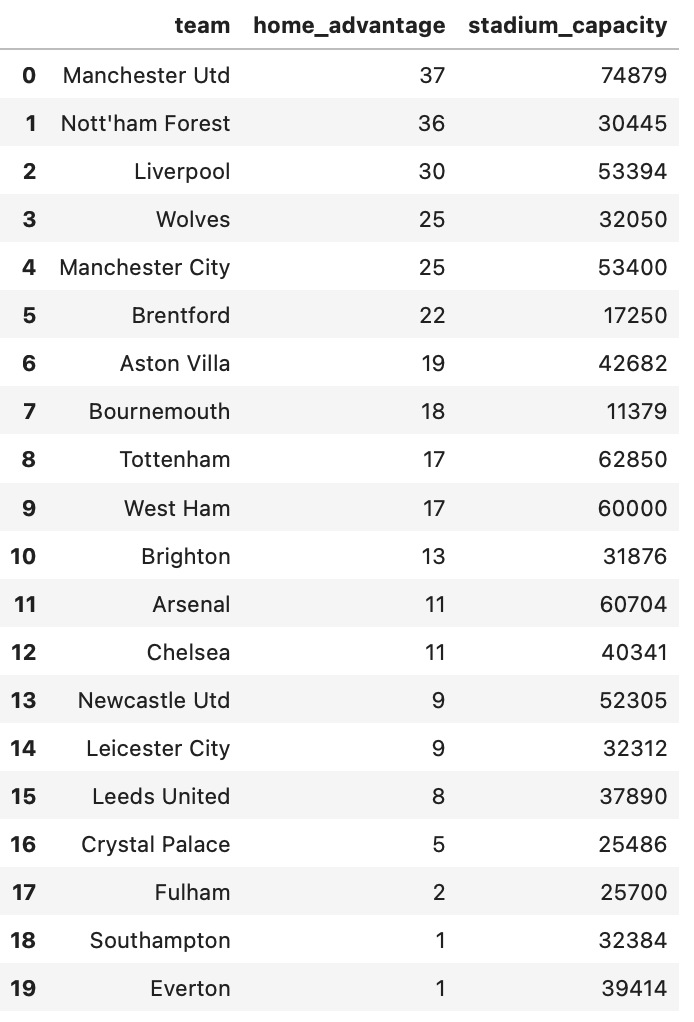

In [21]:
Image("images/home_advantage_df2.png", width=400, height=200)

In [ ]:
# The below then plots a scatter graph using vega altair
stadium_chart = alt.Chart(home_advantage_df).mark_point().encode(
    x=alt.X('stadium_capacity:Q', title='Stadium Capacity'),
    y=alt.Y('home_advantage:Q', title='Home Advantage'),
    tooltip=['team:N', 'stadium_capacity:Q', 'net_home_advantage:Q']
).properties(width=800)

display(stadium_chart)

/Users/maddonk/anaconda3/lib/python3.11/site-packages/altair/utils/core.py:410: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


alt.Chart(...)

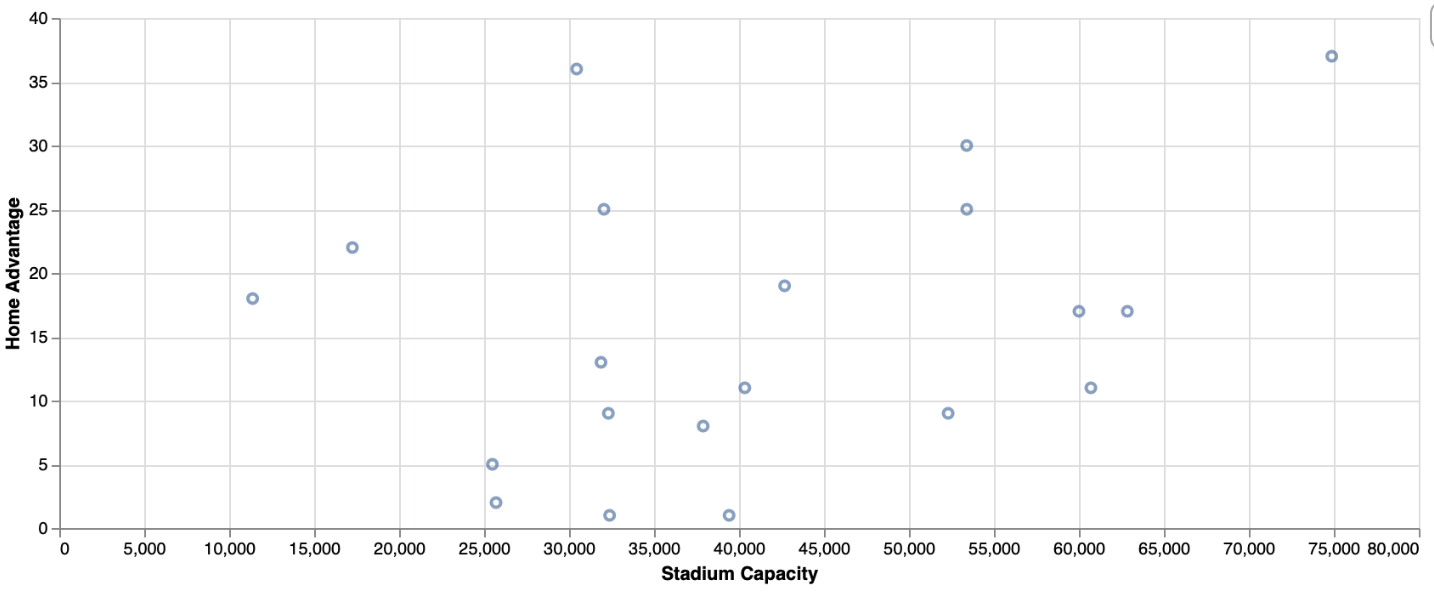

In [23]:
Image("images/stadium_chart.png")

# Query 4: Dream Team by Chosen Stat 

This is a generic query to retrieve a fantasy team (in a 4-3-3 formation) with the highest selected stat for a particular season (excluding goalkeepers). Example query: fantasy team with most goals in 2021-2022 season 


This is another pitch visualistion, this time designed for displaying the best team by chosen stat

In [24]:
def visualise_team(defenders, midfielders, forwards,query_stat):
    ## creating pitch using mplsoccer
    pitch = VerticalPitch(line_color='white', pitch_color='green' )
    fig, ax = pitch.draw(figsize=(16, 8))
    fig.patch.set_facecolor('green')
    def add_image_to_plot(ax, url, x, y):
         ## getting image from link
        response = requests.get(url, timeout=5)
        img_data = BytesIO(response.content)
        img = PILImage.open(img_data)
        imagebox = OffsetImage(img, zoom=0.3)
        ab = AnnotationBbox(imagebox, (x, y), frameon=False)
        ax.add_artist(ab)
            
    # Plot defenders
    for i, defender in enumerate(defenders):
        if i in {3,1}:
            ax.text( 15+ i * 20, 25, f"{defender['player']['name']}", fontsize=12, color='white', ha='center')
        else:
            ax.text( 10+ i * 23, 22.5, f"{defender['player']['name']}", fontsize=12, color='white', ha='center')
        
        x, y =  10+i * 22.5, 35
        add_image_to_plot(ax, defender['player']['img'], x, y)
        ax.text(x + 10, y+5, f"{defender['avg_stat']:.2f}", fontsize=10, color='yellow', ha='center', va='center')
        

    # Plot midfieldersx
    for i, midfielder in enumerate(midfielders):
        ax.text(i*35, 50 , f"{midfielder['player']['name']} ", fontsize=12, color='white')
        x, y = i * 35+5, 60
        add_image_to_plot(ax, midfielder['player']['img'], x, y)
        ax.text(x + 10, y+5, f"{midfielder['avg_stat']:.2f}", fontsize=10, color='yellow', ha='center', va='center')
        
    # Plot forwards
    for i, forward in enumerate(forwards):
        ax.text(i*35, 80, f"{forward['player']['name']} ", fontsize=12, color='white')
        x, y =  i * 35+5, 90
        add_image_to_plot(ax, forward['player']['img'], x, y)
        ax.text(x + 10, y+5, f"{forward['avg_stat']:.2f}", fontsize=10, color='yellow', ha='center', va='center')
    
    title = 'Starting XI Greatest: '+ str(query_stat)
    plt.title(title)
    plt.show()
    

This function is used to find the highest average stat for a given season - this is used for normalisation of player metrics

In [25]:
## method to retrieve player with highest stat during particular season
def find_highest_stat(stat,season):
    query=f"""
    MATCH (p:Player)-[stats:PLAYS_IN]-(m)-[:IS_PART_OF]->(s)
    
    WHERE stats.{stat} IS NOT NULL AND s.season = "{season}"
    with p,m,
    AVG(stats.{stat}) as avg
    ORDER BY avg DESC
    LIMIT 1
    RETURN p.name,avg
    """
    
    with driver.session() as session:
        result = session.run(query)
        for record in result:
            return record['avg']

This method is used to find player with the highest average stat over their whole career - this is used for normalisation of player metrics

In [26]:
## method to find highest average stat of player over all seasons played
def find_highest_stat_oat(stat):
    query=f"""
    MATCH (p:Player)-[stats:PLAYS_IN]-(m)
    
    WHERE stats.{stat} IS NOT NULL 
    with p,m,
    AVG(stats.{stat}) as avg
    ORDER BY avg DESC
    LIMIT 1
    RETURN p.name,avg
    """
    with driver.session() as session:
        result = session.run(query)
        for record in result:
            return record['avg']

 This function contains the parameterised cypher query used for retreiving team with highest specified stat for chosen season

In [142]:
## method retrieves a starting xi (minus a goal keeper) of players in correct positions with the highest chosen stat
def get_top_team_by_stat(season, query_stat):
    query= f"""
        // find defenders that played for squad in season
    MATCH (def:Player)-[:IS_IN_SQUAD]->(squad:Squad)
    WHERE TOUPPER(def.position) CONTAINS "B" AND squad.season = "{season}"
    AND def.img IS NOT NULL

        // retreive stats from match played during season
    MATCH (def)-[stats:PLAYS_IN]-(m)-[:IS_PART_OF]-(s)
    WHERE s.season = "{season}"
    WITH def, AVG(stats.{query_stat}) AS avg_stat, def.img as img

        // Sorting so players with highest stat at top of result
    ORDER BY avg_stat DESC
    LIMIT 4

         // Players image and stat collected and names collected in excluded players list to ensure players with multiple positions do not repeat
    WITH COLLECT(DISTINCT{{player: def, avg_stat: avg_stat, img: img}}) AS defenders,COLLECT(def.name) AS excluded_players

           // find forwards that played for squad in season
    MATCH (fw:Player)-[:IS_IN_SQUAD]->(squad:Squad)
    WHERE TOUPPER(fw.position) CONTAINS "W" AND squad.season = "{season}"

            // Checking player is not already in squad
    AND fw.img IS NOT NULL AND NOT fw.name IN excluded_players
    MATCH (fw)-[stats:PLAYS_IN]-(m)-[:IS_PART_OF]-(s)
    WHERE s.season = "{season}"
    WITH excluded_players, defenders, fw, AVG(stats.{query_stat}) AS avg_stat, fw.img as img
    ORDER BY avg_stat DESC
    LIMIT 3

    WITH defenders, excluded_players as old_excluded_players, COLLECT(DISTINCT{{player: fw, avg_stat: avg_stat, img: img}}) AS forwards,COLLECT(fw.name) AS new_excluded_players
    WITH defenders, forwards, new_excluded_players + old_excluded_players as excluded_players

           // find midfielders that played for squad in season
    MATCH (mid:Player)-[:IS_IN_SQUAD]->(squad:Squad)
    WHERE TOUPPER(mid.position) CONTAINS "M" AND squad.season = "{season}" 
    AND mid.img IS NOT NULL AND NOT mid.name IN excluded_players
    MATCH (mid)-[stats:PLAYS_IN]-(m)-[:IS_PART_OF]-(s)
    WHERE s.season = "{season}"
    WITH defenders,mid,forwards, excluded_players, AVG(stats.{query_stat}) AS avg_stat, mid.img as img
    ORDER BY avg_stat DESC
    LIMIT 3

    WITH defenders,forwards, COLLECT(DISTINCT{{player: mid, avg_stat: avg_stat, img: img}}) AS midfielders

    return defenders,midfielders,forwards
    """
    with driver.session() as session:
        result = session.run(query)
        for record in result:
                defenders = record['defenders']
                midfielders = record['midfielders']
                forwards = record['forwards']
                
                visualise_team(defenders, midfielders, forwards,query_stat)
    driver.close()

This code provides the ui for users to select desired stats and season to view team

In [143]:
## Dropdown boxes for selections
stat_options = [
    "goals", "assists", "penalties", "shots", "shots_on_target", "touches",
    "tackles", "interceptions", "blocks", "xg", "npxg", "xag", "sca", "gca",
    "passes_completed", "passes_attempted", "progressive_passes", "carries"
]
stat_dropdown = widgets.Dropdown(
    options=stat_options,
    value="goals",
    description="Stat:",
    style={'description_width': 'initial'}
)
season_dropdown = widgets.Dropdown(
    options=["2021-2022", "2022-2023", "2023-2024", "2024-2025"],  
    value="2024-2025",
    description="Season:",
    style={'description_width': 'initial'}
)
widgets.interactive(get_top_team_by_stat, query_stat=stat_dropdown, season=season_dropdown)

interactive(children=(Dropdown(description='Season:', index=3, options=('2021-2022', '2022-2023', '2023-2024',…

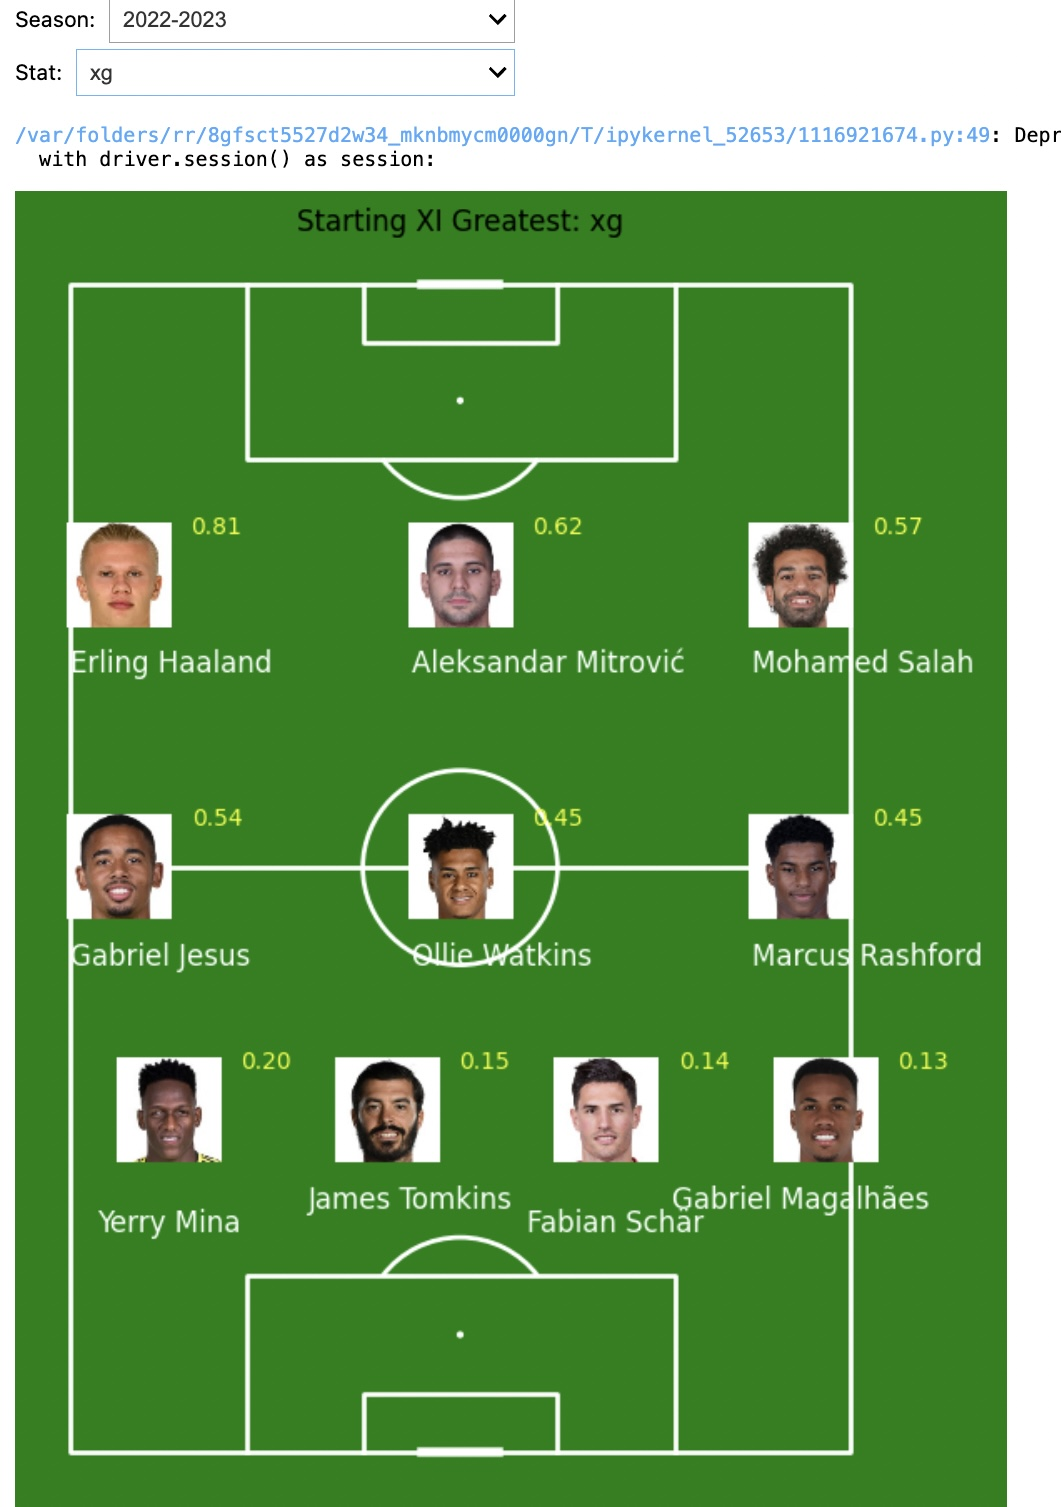

In [144]:
# EXAMPLE USE: Visualisation of greatest xg in season 2022-2023

Image("images/Starting XI Greatest xg.png", width=700, height=350)

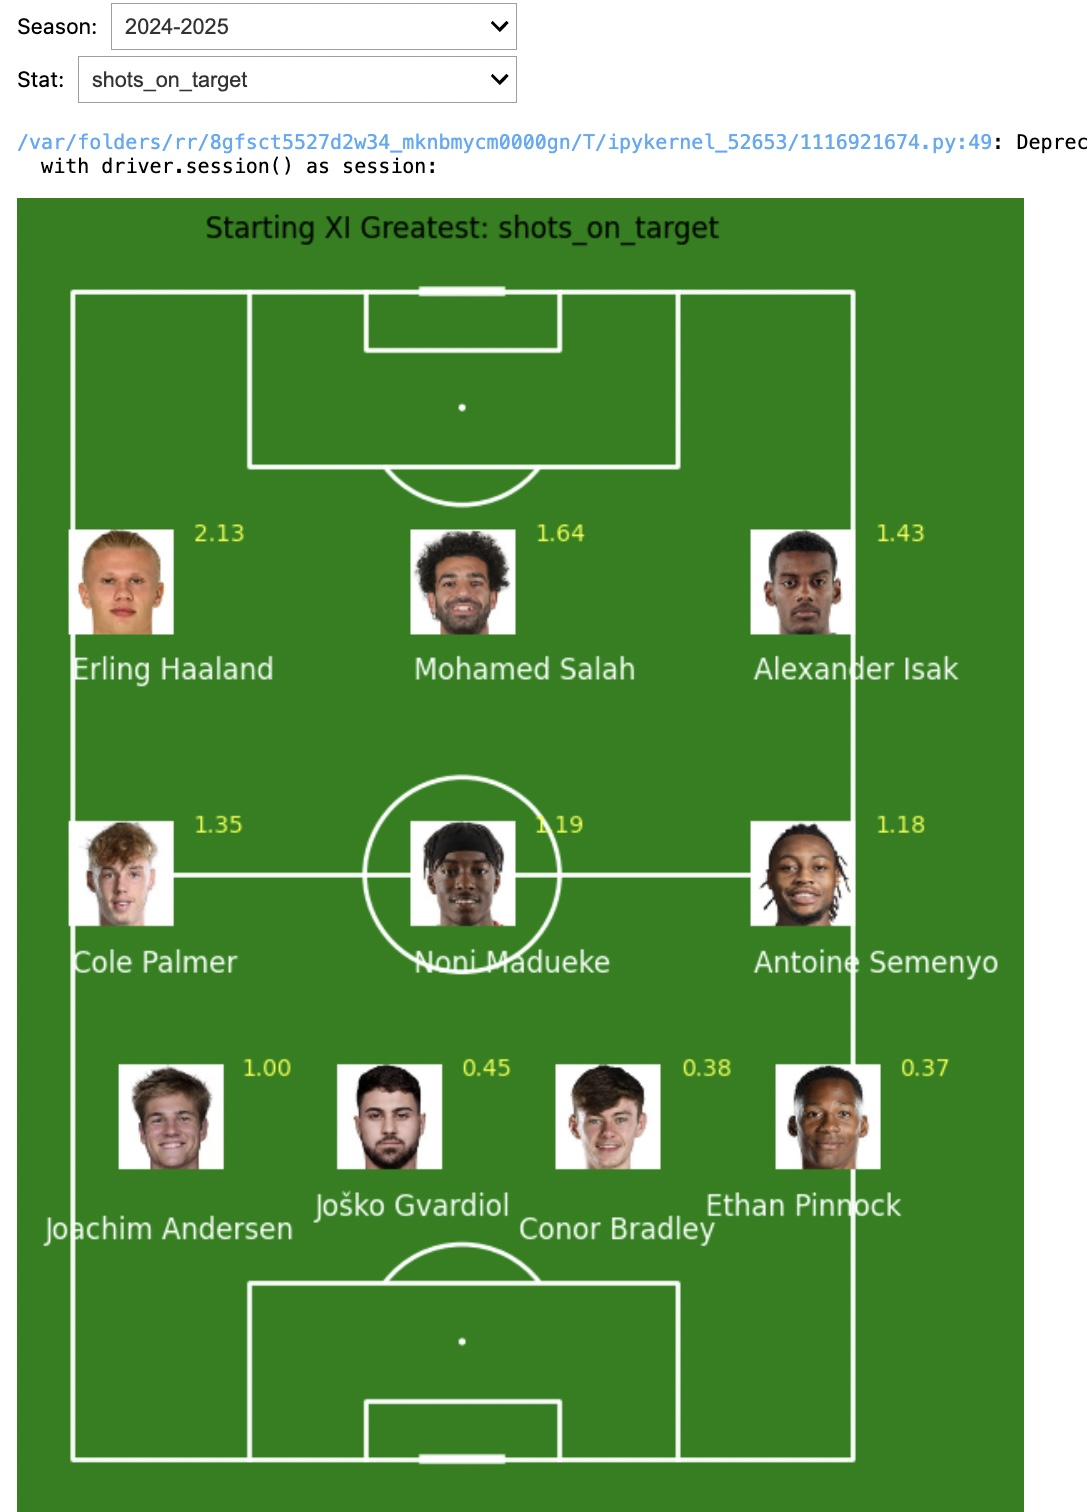

In [145]:
# EXAMPLE USE: Visualisation of Shots on target in season 2024-2025

Image("images/Starting XI Greatest target.png", width=700, height=350)

# Query 5: Get Best Overall Possible Team For Given Season 

This query aims to retrieve a fantasy starting XI with the best overall statistics for a selects season. In order to do this, scores out of 10 are calculated for players from weighted metrics such as goals scored. Different positions have their stats weighted differently with defenders, for example, having their average tackles per game stat weighted higher than average shots. The weightings used are below. The scoring system awards the player with the best overall stats for their position (fw, mid or df) a 10, and the player with the worst overall stats for their position a 0 with score distributed between accordingly. The 4 best defenders, 3 best midfielders 3 top forwards are output to user using mplsoccer and matplotlib for visualisation. 

This function is used to find the highest average stat for a given season - this is used for normalisation of player metrics

In [146]:
## method to retrieve player with highest stat during particular season
def find_highest_stat(stat,season):
    query=f"""
    MATCH (p:Player)-[stats:PLAYS_IN]-(m)-[:IS_PART_OF]->(s)
    
    WHERE stats.{stat} IS NOT NULL AND s.season = "{season}"
    with p,m,
    AVG(stats.{stat}) as avg
    ORDER BY avg DESC
    LIMIT 1
    RETURN p.name,avg
    """
    
    with driver.session() as session:
        result = session.run(query)
        for record in result:
            return record['avg']

- This method uses mpl soccer and matplotlib to produce a visualisation of the dream team 

In [147]:
def visualise_best_team(defenders, midfielders, forwards,season):
    ## creating pitch with mplsoccer
    pitch = VerticalPitch(line_color='white', pitch_color='green' )
    fig, ax = pitch.draw(figsize=(16, 8))
    fig.patch.set_facecolor('green')
    def add_image_to_plot(ax, url, x, y):
        ## getting image from link
        response = requests.get(url, timeout=5)
        img_data = BytesIO(response.content)
        img = PILImage.open(img_data)
        imagebox = OffsetImage(img, zoom=0.3)
        ab = AnnotationBbox(imagebox, (x, y), frameon=False)
        ax.add_artist(ab)
        
        

    # Plot defenders
    for i, defender in enumerate(defenders):
        if i in {3,1}:
            ax.text( 15+ i * 20, 25, f"{defender['player']['name']}", fontsize=12, color='white', ha='center')
        else:
            ax.text( 10+ i * 23, 22.5, f"{defender['player']['name']}", fontsize=12, color='white', ha='center')
        
        x, y =  10+i * 22.5, 35
        add_image_to_plot(ax, defender['player']['img'], x, y)
        stat = defender["normalised_score"]
        ax.text(x + 10, y+5, f"{stat:.2f}", fontsize=10, color='yellow', ha='center', va='center')

    # Plot midfieldersx
    for i, midfielder in enumerate(midfielders):
        ax.text(i*35, 50 , f"{midfielder['player']['name']} ", fontsize=12, color='white')
        x, y = i * 35+5, 60
        add_image_to_plot(ax, midfielder['player']['img'], x, y)
        stat = midfielder["normalised_score"]
        ax.text(x + 10, y+5, f"{stat:.2f}", fontsize=10, color='yellow', ha='center', va='center')


    # Plot forwards
    for i, forward in enumerate(forwards):
        ax.text(i*35, 80, f"{forward['player']['name']} ", fontsize=12, color='white')
        x, y =  i * 35+5, 90
        add_image_to_plot(ax, forward['player']['img'], x, y)
        stat = forward["normalised_score"]
        ax.text(x + 10, y+5, f"{stat:.2f}", fontsize=10, color='yellow', ha='center', va='center')
    title = season+': Best Starting XI Visualization'
    plt.title(title)
    plt.show()

This function contains the cypher query to retrieve the best overall possible team for chosen season

In [236]:
def get_best_team(season):
   ## Here the max of every stat used to calculate player scores is calculated for later in normalisation process
    max_blocks=find_highest_stat("blocks",season)
    max_shots=find_highest_stat("shots",season)
    max_interceptions=find_highest_stat("interceptions",season)
    max_tackles=find_highest_stat("tackles",season)
    max_goals=find_highest_stat("goals",season)
    max_assists=find_highest_stat("assists",season)
    max_xg = find_highest_stat("xg",season)
    max_carries = find_highest_stat("progressive_carries",season)
    max_pass = find_highest_stat("progressive_passes",season)

    query= f"""
         // Matching defenders that played in squads during specific year and retrieving their stats while playing in position
    
    MATCH (def)-[stats:PLAYS_IN]-(m)-[:IS_PART_OF]-(s)
    WHERE s.season = "{season}"
    MATCH (def:Player)-[:IS_IN_SQUAD]->(squad:Squad)
    WHERE TOUPPER(stats.position) CONTAINS "B" AND squad.season = "{season}"
    AND def.img IS NOT NULL

        // averages for every stat calculated
    WITH def,
        AVG(stats.blocks) AS avg_blocks,
        AVG(stats.interceptions) AS avg_interceptions,
        AVG(stats.tackles) AS avg_tackles,
        AVG(stats.goals) AS avg_goals,
        AVG(stats.assists) AS avg_assists,
        AVG(stats.xg) as avg_xg,
        AVG(stats.progressive_carries) as avg_carries,
        AVG(stats.progressive_passes) as avg_pass,
        def.img as img

            // averages normalised by max stats retrieved earlier to ensure stats that are typically lower (e.g progressive passes > goals) are accounted for
            // Weights are also applied so that scores are reflective of positions
    WITH def, img,
        0.2 * (avg_blocks / {max_blocks}) +
        0.2 * (avg_interceptions / {max_interceptions}) +
        0.2 * (avg_tackles  / {max_tackles} ) +
        0.05 * (avg_goals / {max_goals})+
        0.05 * (avg_assists/ {max_assists})+
        0.05 *(avg_xg/{max_xg})+
        0.05*(avg_carries/{max_carries})+
        0.2*(avg_pass/{max_pass})
    AS raw_performance_score

            // Highest scores at the top
    ORDER BY raw_performance_score DESC

            //Players stored in order, excluded_players populated to avoid repeating players (multiple positions)
    WITH COLLECT(DISTINCT{{player: def, performance: raw_performance_score, img: img}}) AS defenders,COLLECT(def.name) AS excluded_players,

             // Min and max scores for position calculated for later normalisation
        MIN(raw_performance_score) AS min_def_score, 
        MAX(raw_performance_score) AS max_def_score

        

        // Matching forwards that played in squads during specific year and retrieving their stats
    

             // Ensure player has not already been selected
    
    MATCH (fw)-[stats:PLAYS_IN]-(m)-[:IS_PART_OF]-(s)
    WHERE s.season = "{season}"AND NOT fw.name IN excluded_players
    MATCH (fw:Player)-[:IS_IN_SQUAD]->(squad:Squad)     
    WHERE TOUPPER(stats.position) CONTAINS "W" AND squad.season = "{season}"
    


        // averages for every stat calculated
    WITH fw, defenders,min_def_score, max_def_score,excluded_players,
        AVG(stats.goals) AS avg_goals,
        AVG(stats.assists) AS avg_assists,
        AVG(stats.xg) as avg_xg,
        AVG(stats.progressive_carries) as avg_carries,
        AVG(stats.progressive_passes) as avg_pass,
        AVG(stats.shots) as avg_shots

            // averages normalised by max stats retrieved earlier to ensure stats that are typically lower (e.g progressive passes > goals) are accounted for
            // Weights are also applied so that scores are reflective of positions  
    WITH defenders,fw,min_def_score, max_def_score,excluded_players,
        0.15*(avg_shots/{max_shots})+
        0.5 * (avg_goals / {max_goals})+
        0.1 * (avg_assists/ {max_assists})+
        0.175 *(avg_xg/{max_xg})+
        0.05*(avg_carries/{max_carries})+
        0.025*(avg_pass/{max_pass}) as raw_performance_score,
        fw.img AS img
    ORDER BY raw_performance_score DESC

    WITH defenders,min_def_score, max_def_score, excluded_players as old_excluded_players, COLLECT({{player: fw, performance:raw_performance_score, img: img}}) AS forwards,COLLECT(fw.name) AS new_excluded_players,
              // For later normalisation
        MIN(raw_performance_score) AS min_fw_score, 
        MAX(raw_performance_score) AS max_fw_score

    WITH defenders, forwards, new_excluded_players + old_excluded_players as excluded_players,min_def_score, max_def_score, min_fw_score, max_fw_score
 

        


         // Matching midfeilders that played in squads during specific year and retrieving their stats
    MATCH (mid)-[stats:PLAYS_IN]-(m)-[:IS_PART_OF]-(s)
    WHERE s.season = "{season}" AND NOT mid.name IN excluded_players
    MATCH (mid:Player)-[:IS_IN_SQUAD]->(squad:Squad)
    WHERE TOUPPER(stats.position) CONTAINS "M" AND squad.season = "{season}" 
   
    
        // averages for every stat calculated
    with defenders, mid,forwards, min_def_score, max_def_score, min_fw_score, max_fw_score,
        AVG(stats.interceptions) AS avg_interceptions,
        AVG(stats.tackles) AS avg_tackles,
        AVG(stats.goals) AS avg_goals,
        AVG(stats.assists) AS avg_assists,
        AVG(stats.xg) as avg_xg,
        AVG(stats.progressive_carries) as avg_carries,
        AVG(stats.progressive_passes) as avg_pass,
        AVG(stats.shots) as avg_shots,
        mid.img as img

        // averages normalised by max stats retrieved earlier to ensure stats that are typically lower (e.g progressive passes > goals) are accounted for
        // Weights are also applied so that scores are reflective of positions
    with defenders, mid, img,forwards, min_def_score, max_def_score, min_fw_score, max_fw_score,
        0.1*(avg_shots/{max_shots})+
        0.1 * (avg_interceptions / {max_interceptions}) +
        0.1 * (avg_tackles  / {max_tackles} ) +
        0.3 * (avg_goals / {max_goals})+
        0.1 * (avg_assists/ {max_assists})+
        0.1 *(avg_xg/{max_xg})+
        0.1*(avg_carries/{max_carries})+
        0.1*(avg_pass/{max_pass}) as raw_performance_score

    ORDER BY raw_performance_score DESC


    WITH defenders,forwards,min_def_score, max_def_score, min_fw_score, max_fw_score,  COLLECT({{player: mid, performance: raw_performance_score, img: img}}) AS midfielders,
    MIN(raw_performance_score) AS min_mid_score,
        MAX(raw_performance_score) AS max_mid_score

        // Final normalisation to give score out of ten

    WITH defenders, forwards, midfielders,
        min_def_score, max_def_score, 
        min_fw_score, max_fw_score, 
        min_mid_score, max_mid_score

        
        // Below gives worst player score of 0, and best player a 10
        // Limits are applied to return a 4-3-3 formation

        // defender normalisation
    UNWIND defenders AS def
    WITH def, (def.performance - min_def_score) / (max_def_score - min_def_score) * 10 AS normalised_score,
        forwards, midfielders,
        min_fw_score, max_fw_score, 
        min_mid_score, max_mid_score
    LIMIT 4

        // forward normalisation
    WITH COLLECT({{player: def.player, performance: def.performance, img: def.img, normalised_score: normalised_score}}) AS defenders,
        forwards, midfielders,
        min_fw_score, max_fw_score, 
        min_mid_score, max_mid_score


    UNWIND forwards AS fw
    WITH fw, (fw.performance - min_fw_score) / (max_fw_score - min_fw_score) * 10 AS normalised_score,
        defenders, midfielders,
        min_mid_score, max_mid_score
    LIMIT 3

        //midfielder normalisation
    WITH defenders, COLLECT({{player: fw.player, performance: fw.performance, img: fw.img, normalised_score: normalised_score}}) AS forwards, midfielders, min_mid_score, max_mid_score
    UNWIND midfielders AS mid
    WITH mid, (mid.performance - min_mid_score) / (max_mid_score - min_mid_score) * 10 AS normalised_score,
        defenders, forwards
    LIMIT 3
    WITH defenders, forwards, COLLECT({{player: mid.player, performance: mid.performance, img: mid.img, normalised_score: normalised_score}}) AS midfielders

    return defenders,midfielders,forwards
    """

    with driver.session() as session:
        result = session.run(query)
        for record in result:
                defenders = record['defenders']
                midfielders = record['midfielders']
                forwards = record['forwards']
                visualise_best_team(defenders, midfielders, forwards,season)
    driver.close()

This code block contains UI for user to interact and view team

In [ ]:
season_dropdown2 = widgets.Dropdown(
    options=["2021-2022", "2022-2023", "2023-2024", "2024-2025"],  
    value="2024-2025",
    description="Season:",
    style={'description_width': 'initial'}
)
widgets.interactive(get_best_team, season=season_dropdown2)

interactive(children=(Dropdown(description='Season:', index=3, options=('2021-2022', '2022-2023', '2023-2024',…

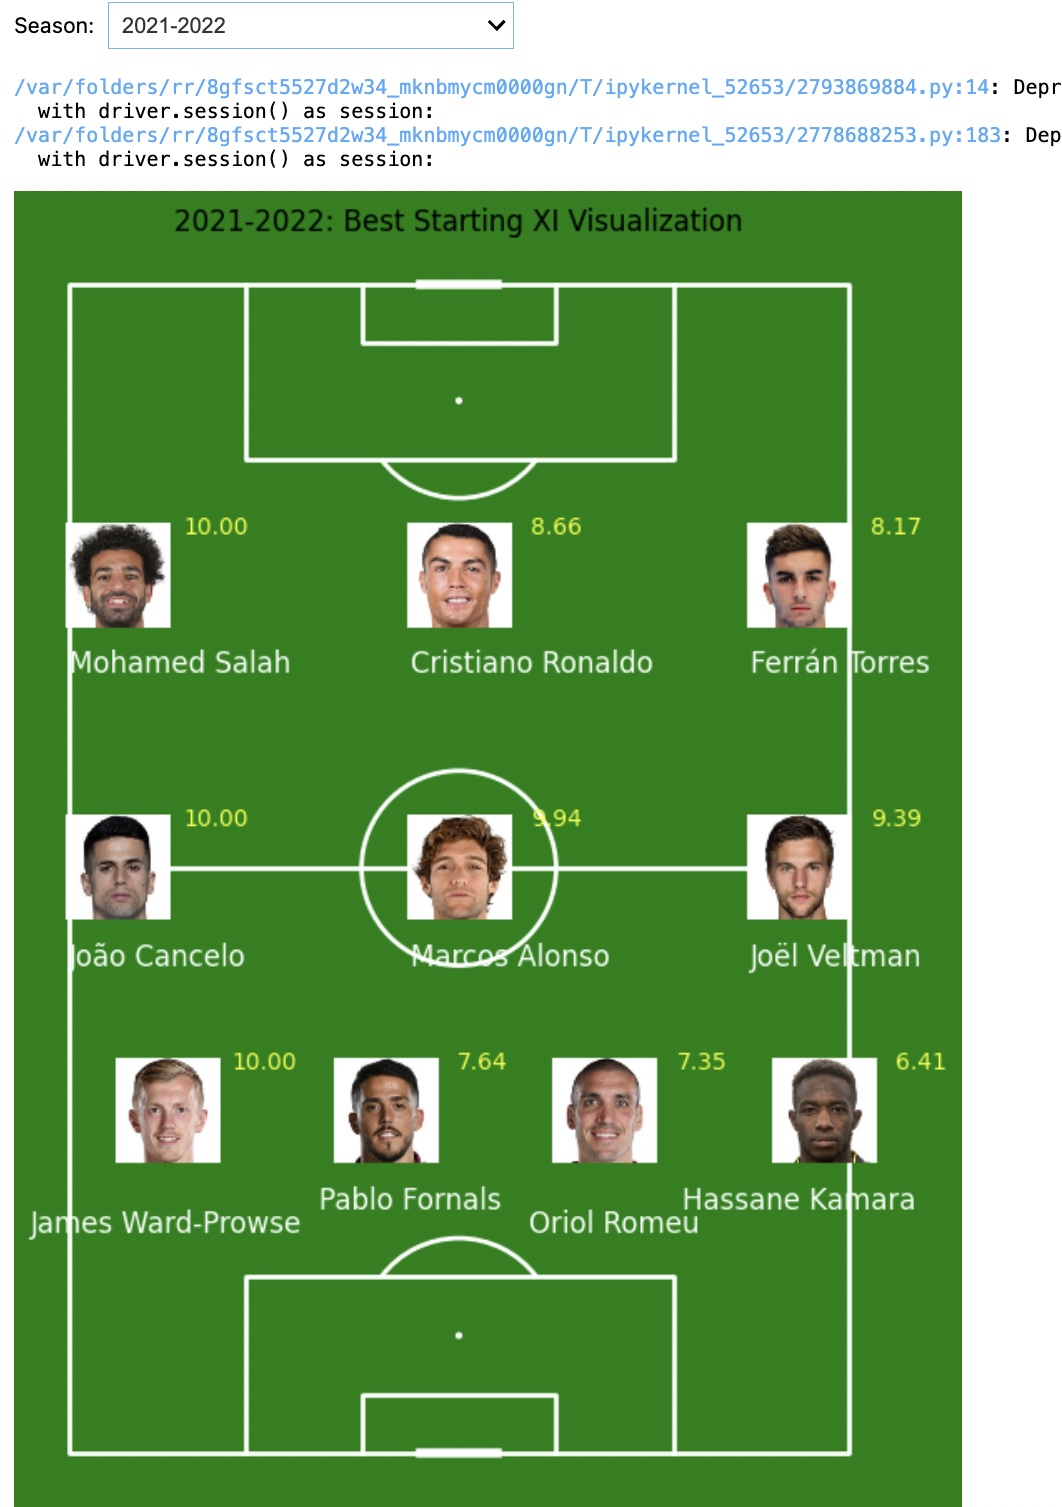

In [238]:
# EXAMPLE USE: Visualisation of 2021-2022 Season

Image("images/Best Starting XI Visualization1.png", width=700, height=350)

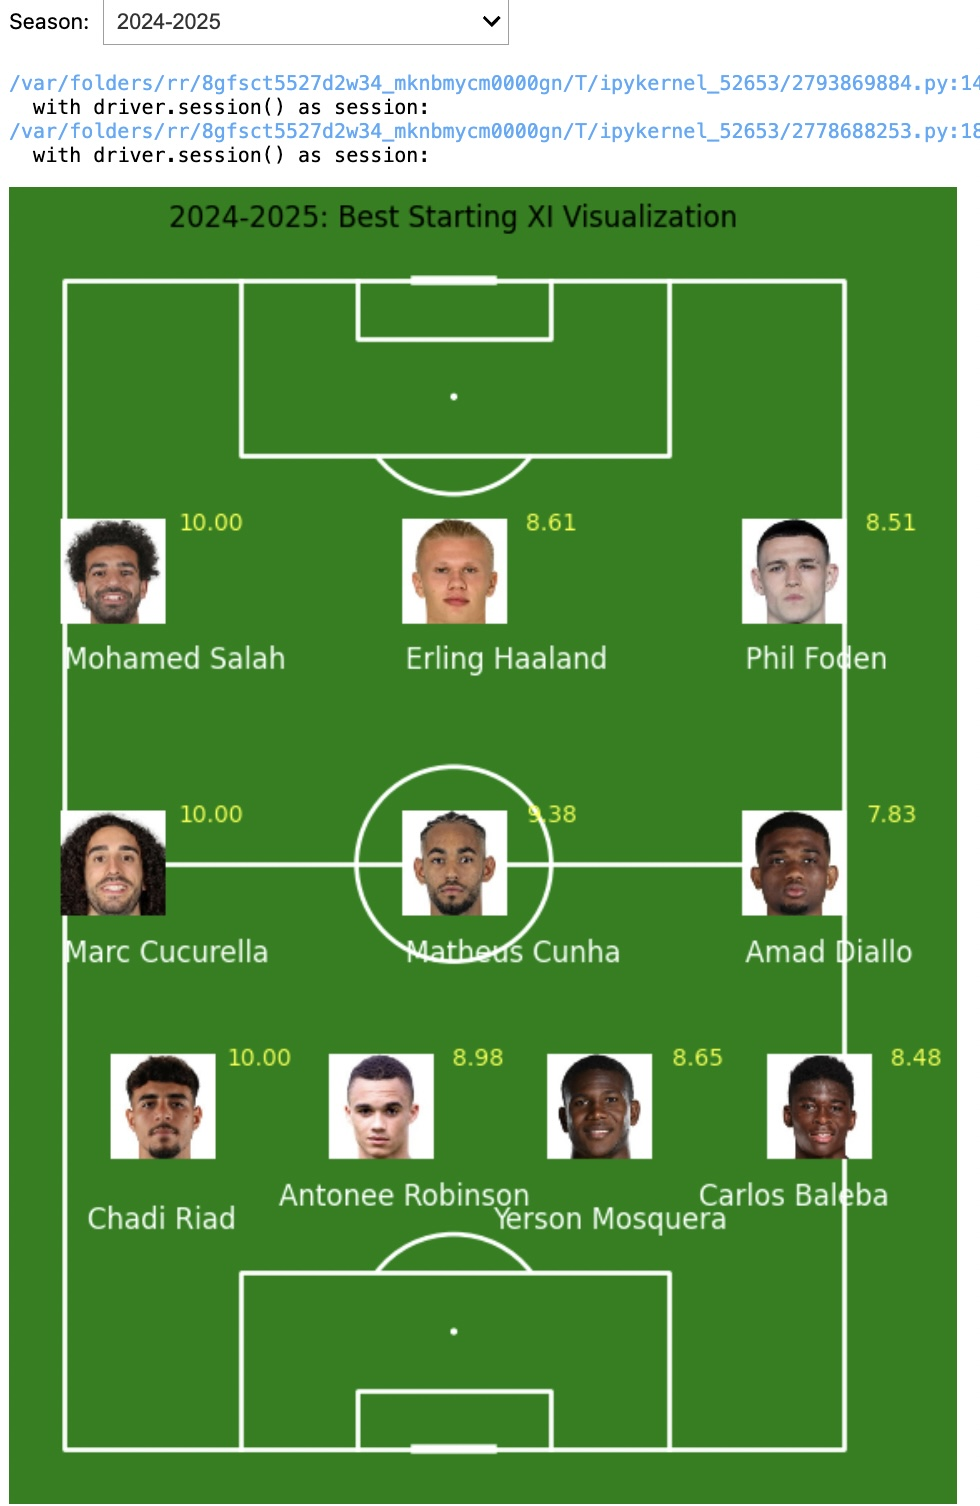

In [239]:
# EXAMPLE USE: Visualisation of 2021-2022 Season

Image("images/Best Starting XI Visualization2.png", width=700, height=350)

# Query 6: Defender with Most Growth between any Two Seasons

This query aims to retrieve a list of defenders that had the greatest season on season improvement in their raw peformance score (defined above in previous query above)

This method is used to find player with the highest average stat over their whole career - this is used for normalisation of player metrics

In [240]:

## method to find highest average stat of player over all seasons played
def find_highest_stat_oat(stat):
    query=f"""
    MATCH (p:Player)-[stats:PLAYS_IN]-(m)
    
    WHERE stats.{stat} IS NOT NULL 
    with p,m,
    AVG(stats.{stat}) as avg
    ORDER BY avg DESC
    LIMIT 1
    RETURN p.name,avg
    """
    with driver.session() as session:
        result = session.run(query)
        for record in result:
            return record['avg']

This method contains cypher query to retrieve the greatest percentage increase in raw_peformance_scores for defeneders

In [241]:
import pandas as pd
max_blocks=find_highest_stat_oat("blocks")
max_shots=find_highest_stat_oat("shots")
max_interceptions=find_highest_stat_oat("interceptions")
max_tackles=find_highest_stat_oat("tackles")
max_goals=find_highest_stat_oat("goals")
max_assists=find_highest_stat_oat("assists")
max_xg = find_highest_stat_oat("xg")
max_carries = find_highest_stat_oat("progressive_carries")
max_pass = find_highest_stat_oat("progressive_passes")
query=f"""
WITH ["2021-2022", "2022-2023", "2023-2024", "2024-2025"] AS seasons

// Loops through every two season stopping at "2023-2024", "2024-2025"
// The logic for looping through seasons was created with aid from ChatGPT
UNWIND RANGE(0, SIZE(seasons) - 2) AS season_id
WITH seasons[season_id] AS season1, seasons[season_id + 1] AS season2

MATCH (def:Player)-[:IS_IN_SQUAD]->(squad:Squad)
WHERE TOUPPER(def.position) CONTAINS "B"

// Retrieving stats from previous and current season
MATCH (def)-[stats1:PLAYS_IN]->(m1:Match)-[:IS_PART_OF]->(s1)
WHERE s1.season = season1


MATCH (def)-[stats2:PLAYS_IN]-(m2:Match)-[:IS_PART_OF]-(s2)
WHERE s2.season = season2

// Calculating averages of all stats
WITH def, season1, season2,
AVG(stats1.blocks) AS avg_blocks1,
AVG(stats1.interceptions) AS avg_interceptions1,
AVG(stats1.tackles) AS avg_tackles1,
AVG(stats1.goals) AS avg_goals1,
AVG(stats1.assists) AS avg_assists1,
AVG(stats1.xg) as avg_xg1,
AVG(stats1.progressive_carries) as avg_carries1,
AVG(stats1.progressive_passes) as avg_pass1,
AVG(stats2.blocks) AS avg_blocks2,
AVG(stats2.interceptions) AS avg_interceptions2,
AVG(stats2.tackles) AS avg_tackles2,
AVG(stats2.goals) AS avg_goals2,
AVG(stats2.assists) AS avg_assists2,
AVG(stats2.xg) as avg_xg2,
AVG(stats2.progressive_carries) as avg_carries2,
AVG(stats2.progressive_passes) as avg_pass2

// Applying weighting for each stat, 
// This time using the best average stats of all time to weight in order to ensure comparibility
WITH def, season1, season2,
0.2 * (avg_blocks1 / {max_blocks}) +
0.2 * (avg_interceptions1 / {max_interceptions}) +
0.2 * (avg_tackles1  / {max_tackles}) +
0.05 * (avg_goals1 / {max_goals})+
0.05 * (avg_assists1/ {max_assists})+
0.05 *(avg_xg1/{max_xg})+
0.05*(avg_carries1/{max_carries})+
0.2*(avg_pass1/30) AS score_1,

0.2 * (avg_blocks2 /  {max_blocks}) +
0.2 * (avg_interceptions2 /  {max_interceptions}) +
0.2 * (avg_tackles2  / {max_tackles} ) +
0.05 * (avg_goals2 / {max_goals})+
0.05 * (avg_assists2/ {max_assists})+
0.05 *(avg_xg2/{max_xg})+
0.05*(avg_carries2/{max_carries})+
0.2*(avg_pass2/30) AS score_2

// Remove players with score_1 = 0 to avoid division by zero
WHERE score_1 > 0

WITH def, season1, season2, score_1, score_2, (score_2 - score_1)/score_1*100 AS growth

ORDER BY growth DESC

WITH def, season1, season2, score_1, score_2, growth
LIMIT 10

RETURN def.name AS player, season1, season2, score_1, score_2, growth
"""
growth_data = []
with driver.session() as session:
    result = session.run(query)
    for record in result:
            growth_data.append({"Player":record["player"],"Growth (%)":record["growth"],"Seasons":record["season1"]+"-->"+record["season2"]})
driver.close()
growth_df = pd.DataFrame(growth_data)
growth_df

/var/folders/rr/8gfsct5527d2w34_mknbmycm0000gn/T/ipykernel_85808/3361544632.py:13: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:
/var/folders/rr/8gfsct5527d2w34_mknbmycm0000gn/T/ipykernel_85808/551605866.py:83: DeprecationWarning: Using a driver after it has been closed is deprecated. Future versions of the driver will raise an error.
  with driver.session() as session:


,Player,Growth (%),Seasons
0,Neco Williams,530.280904,2021-2022-->2022-2023
1,Jamaal Lascelles,294.295306,2022-2023-->2023-2024
2,Tyrone Mings,261.713326,2023-2024-->2024-2025
3,Matt Ritchie,236.197076,2022-2023-->2023-2024
4,Cody Drameh,164.638391,2021-2022-->2022-2023
5,Ainsley Maitland-Niles,122.993871,2021-2022-->2022-2023
6,Ben Johnson,104.618007,2023-2024-->2024-2025
7,Jaïro Riedewald,95.256653,2022-2023-->2023-2024
8,Matt Doherty,95.055947,2023-2024-->2024-2025
9,Lisandro Martínez,94.573949,2023-2024-->2024-2025


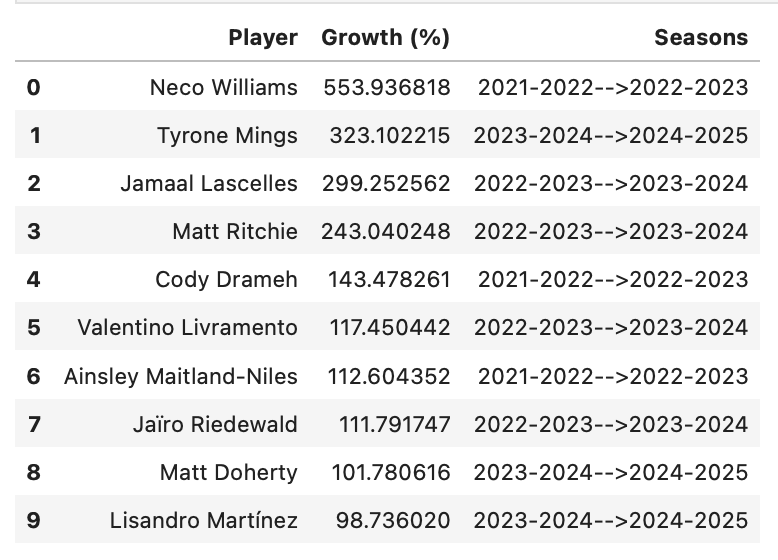

In [242]:
Image("images/growth_df.png", width=600, height=300)

### Query 6 Visualisation

In [243]:

plt.figure(figsize=(10, 6))
plt.barh((growth_df["Player"]+" "+growth_df"Seasons"]), growth_df["Growth (%)"], color='skyblue')
plt.xlabel("Growth (%)")
plt.ylabel("Player")
plt.title("Top Defender Growth Over Seasons")


SyntaxError: closing parenthesis ']' does not match opening parenthesis '(' (144194406.py, line 2)

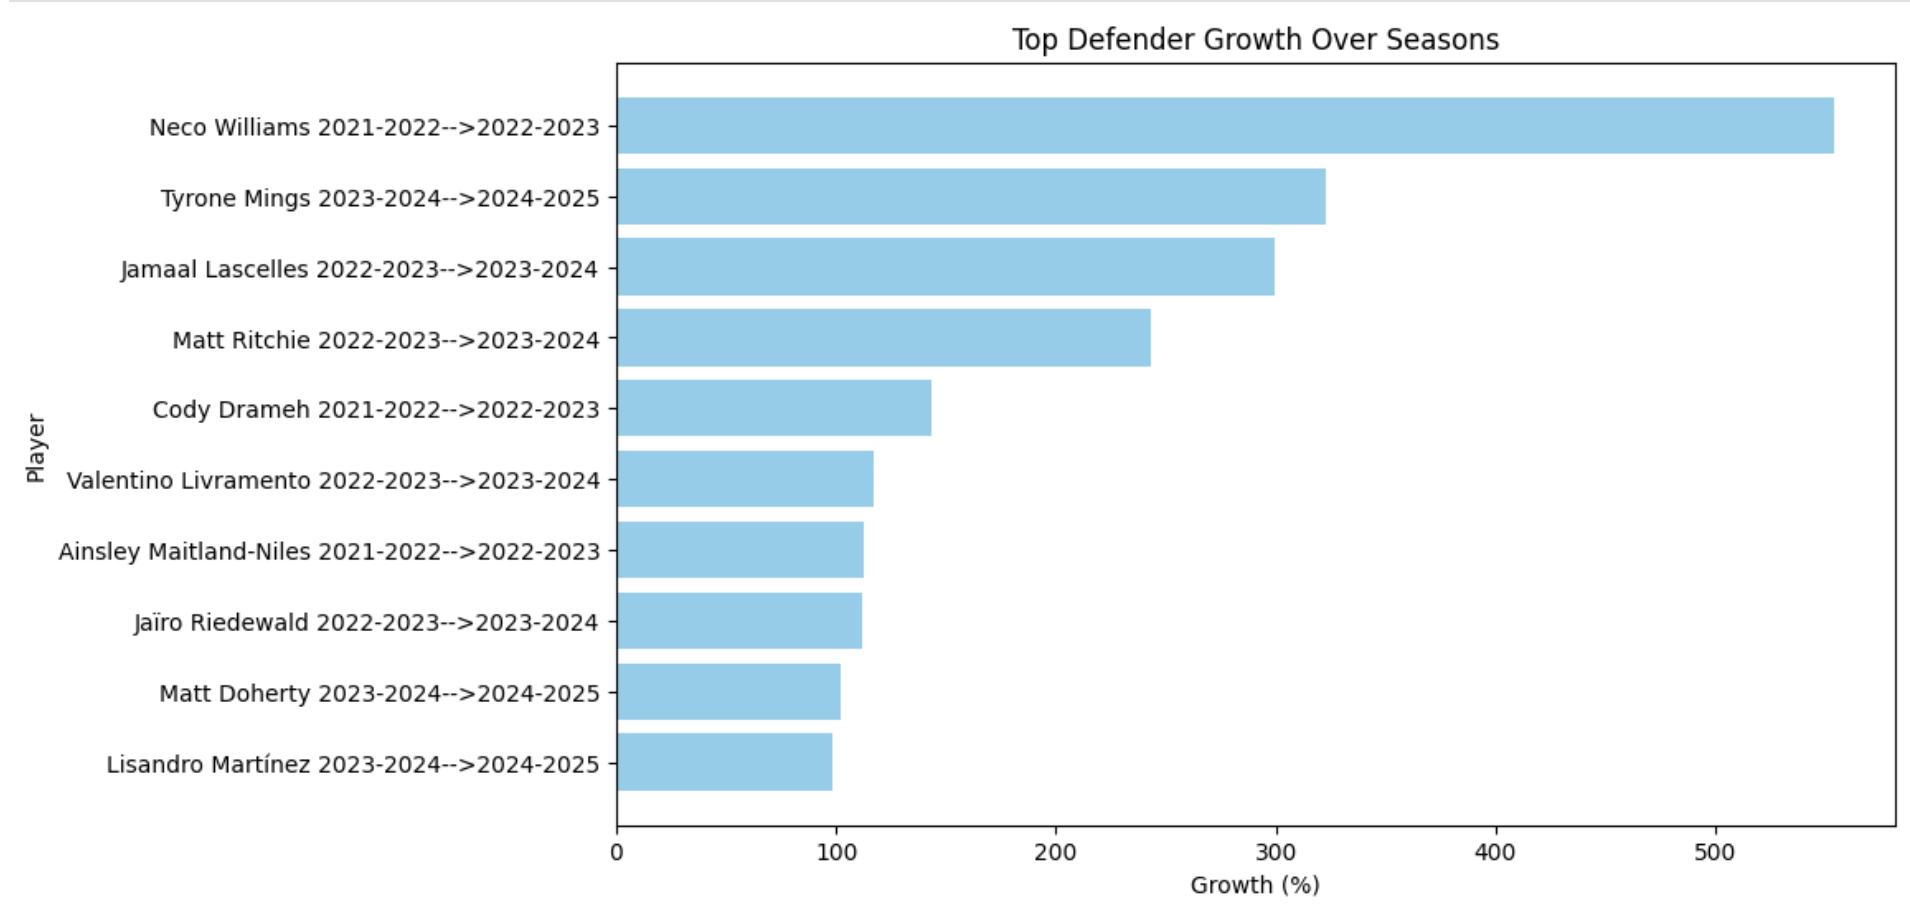

In [78]:
Image("images/Top growth.png")

# Query 7: League Visualiser 

This query presents the league table for all the years stored within the database. This is to evaluate a teams performance in a given year.

In [ ]:
# initiate relevant objects to retrieve league rankings
env_path = os.path.join(os.getcwd(), 'config/.env')
load_dotenv(dotenv_path=env_path)
CQL = CypherQueryLoader(os.path.join(os.getcwd(), 'queries'))

# retreive instance login details and set up driver
NEO4J_URI = os.getenv("NEO4J_URI")
NEO4J_USERNAME = os.getenv("NEO4J_USERNAME")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD")
driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USERNAME, NEO4J_PASSWORD))

def get_unique_seasons():
    """
    Function to make the query to retrieve all seasons which are stored within the databse. 
    """
    query = "MATCH (s:Season) RETURN s.season AS season_name ORDER BY season_name"
    with driver.session(database="neo4j") as session:
        result = session.run(query)
        return [record['season_name'] for record in result]

def fetch_league_for_season(season_name):
    """
    Reads in the template query file for league ranking retrieval and executes. Returns dataframe with columns Rank, Team Name, Points, Goal Diffference"
    season_name: str
    """
    
    league_query = CQL.load_query("league_rankings")
    
    with driver.session(database="neo4j") as session:
        result = session.run(league_query, parameters={"season_name": season_name})
        df = pd.DataFrame(result.values(), columns=["Team Name", "Points", "Goal Difference"])
        df["Rank"] = range(1, len(df) + 1)
        df.set_index("Rank", inplace=True)
        return df
        
def on_season_button_clicked(season_name):
    """
    Function called when one of the season buttons is pressed. Refreshes output in jupyter cell and displays league table
    """
    with output:
        clear_output(wait=True)
        print(f"League Table: {season_name}")
        df = fetch_league_for_season(season_name)
        display(df)


output = widgets.Output()
season_buttons = []
# create a button for every league stored in the instance
for season in get_unique_seasons():
    button = widgets.Button(description=season, layout=widgets.Layout(width="150px"))
    button.on_click(lambda b, s=season: on_season_button_clicked(s))
    season_buttons.append(button)
    
# display them in a grid
grid = widgets.GridBox(season_buttons, layout=widgets.Layout(grid_template_columns="repeat(5, 150px)"))

display(grid, output)


GridBox(children=(Button(description='2021-2022', layout=Layout(width='150px'), style=ButtonStyle()), Button(d…

Output()

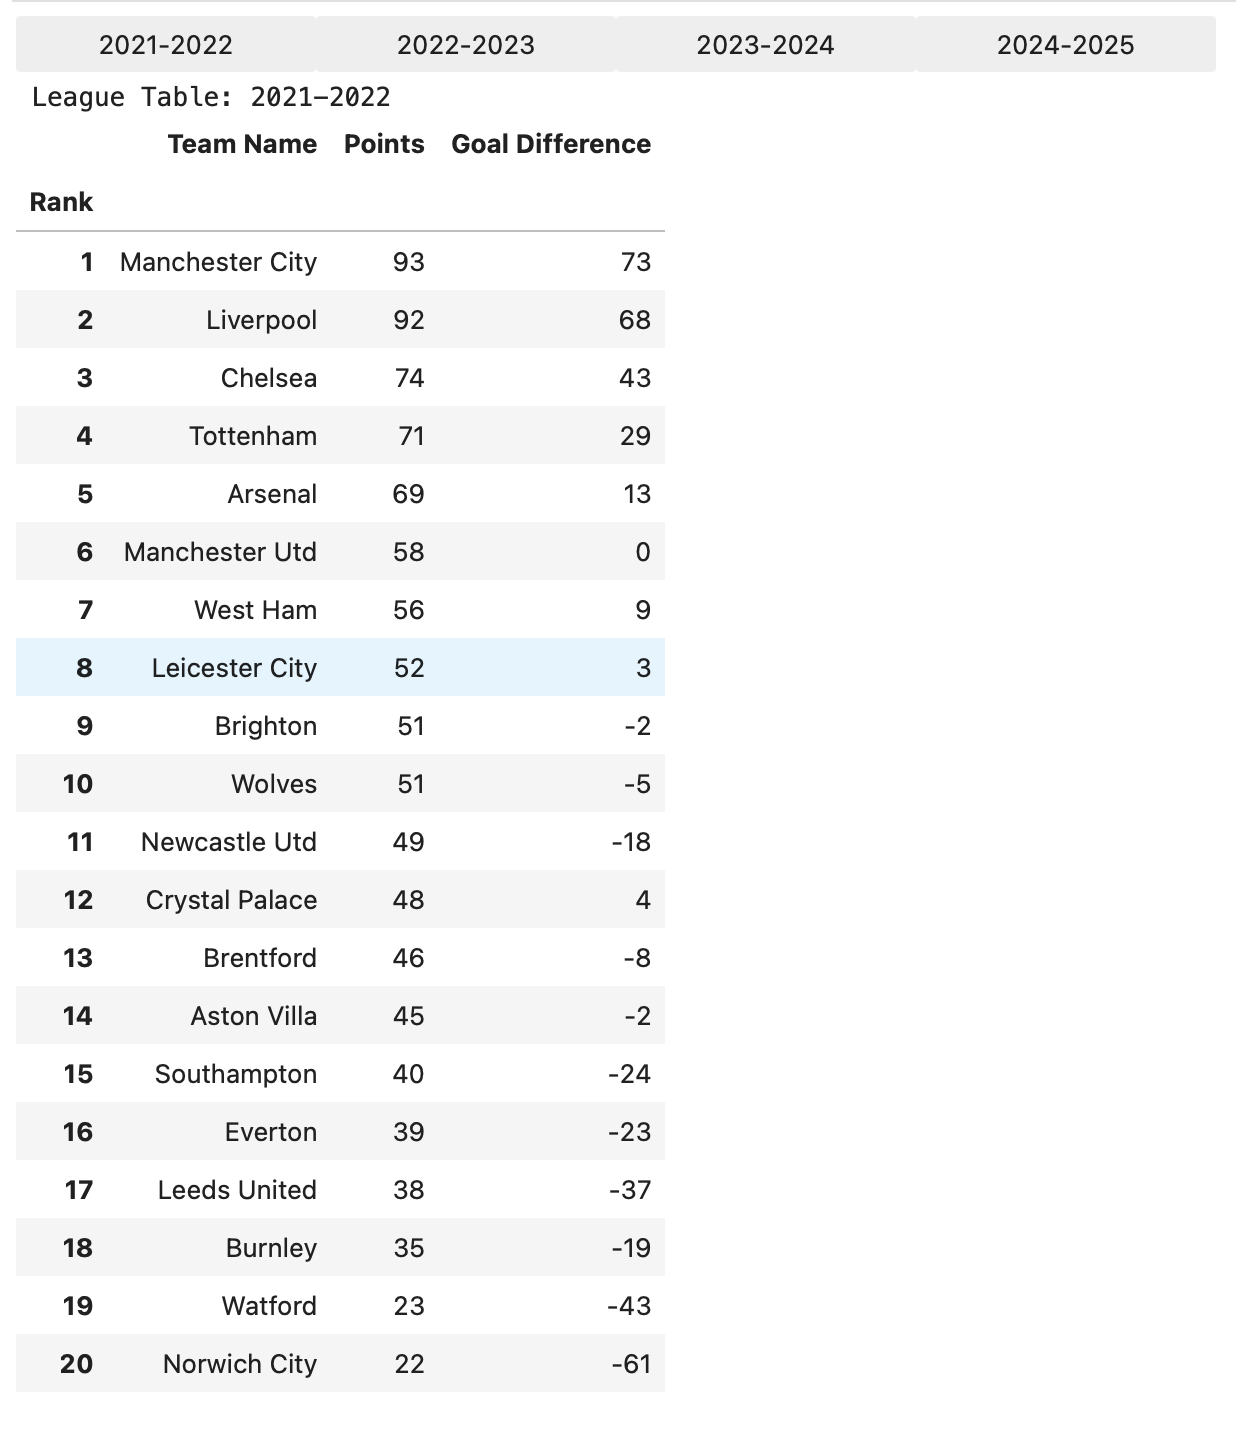

In [80]:
Image("images/league_table_2021.png", width=600, height=300)

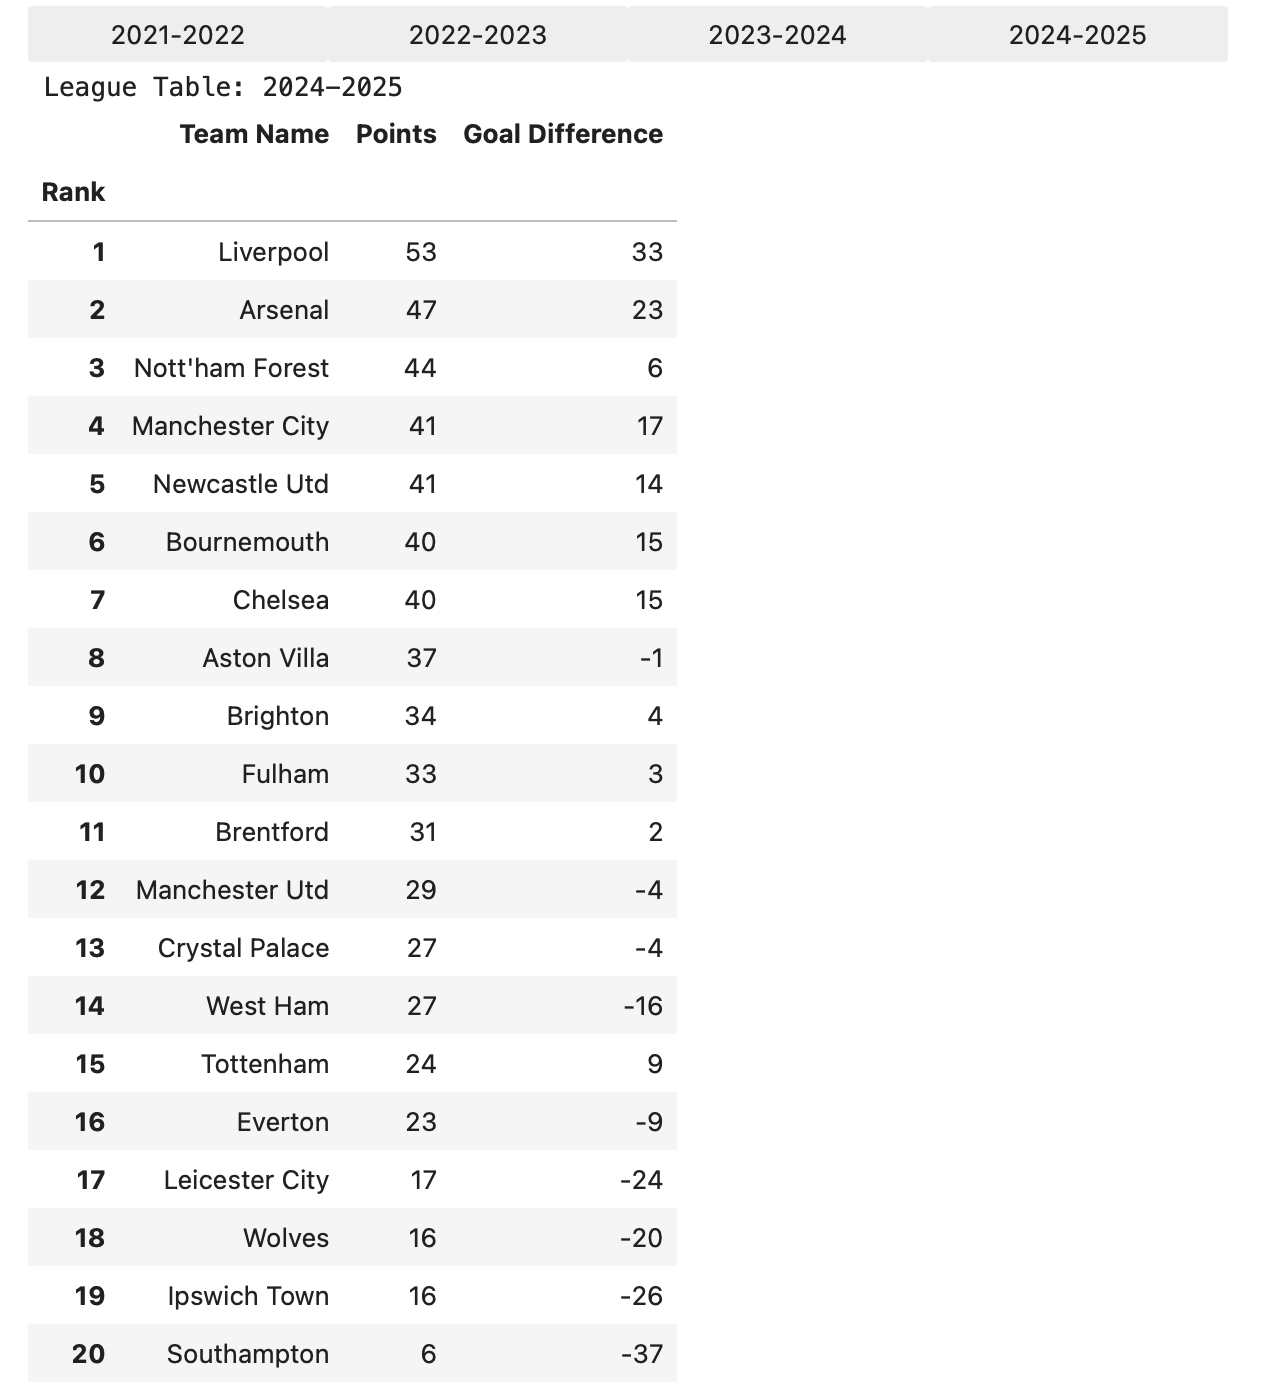

In [81]:
Image("images/league_table_2024.png", width=600, height=300)